# Домашнее задание

Запрограммировать на Python небольшую рекуррентную сеть (≈ 3 нейрона) без внешних входов, экспериментально подобрать коэффициенты, при которых наблюдаются:

1) Сходимость к аттрактору – с какого‑то момента времени $y(t) = y(t-1)$.
2) Предельный цикл, т.е. $y(t) = y(t-k)$, наблюдается периодичность.
3) Насыщение.

Построить графики изменения выходов нейронов в зависимости от времени.

In [191]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [192]:
class RecursiveNeuralNetwork:
    def __init__(self, inits, weights, functions, bias=None, input_weights=None):
        self.y = np.array(inits, dtype=float).reshape(-1, 1)
        self.n = len(self.y)

        self.W = np.array(weights)
        assert self.n == self.W.shape[0] == self.W.shape[1]

        self.f = np.array(functions, dtype=object)
        assert self.n == len(self.f)

        if bias is None:
            self.b = np.zeros(self.n).reshape(-1, 1)
        else:
            self.b = np.array(bias).reshape(-1, 1)

        if input_weights is None:
            self.U = np.zeros((self.n, self.n))
        else:
            self.U = np.array(input_weights)
        
        self.t = 0

    def forward(self, x=None):
        if x is None:
            x = np.zeros(self.n)
        x = x.reshape(-1, 1)
        z = self.U @ x + self.W @ self.y + self.b
        self.y = np.array([f(yi) for f, yi in zip(self.f, z.flat)]).reshape(-1, 1)
        self.t += 1
        return self.y
    
    def visualize(self, ax=None, show_weights=True, show_values=True, 
                node_size=650, font_size=10):
        """
        Visualize RNN in circular layout with neuron values and weight labels.
        
        Parameters:
        -----------
        show_values : bool, default=True
            Display current activation values next to neurons.
        show_weights : bool, default=True
            Display edge weights near arrow starts (30% from source).
        """
        import matplotlib.pyplot as plt
        import networkx as nx
        import numpy as np
        
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(10, 10), facecolor='white')
        else:
            fig = None
        
        G = nx.DiGraph()
        n_inputs = self.U.shape[1]
        n_hidden = self.W.shape[0]
        
        # Create nodes
        input_nodes = [f"x{i}" for i in range(n_inputs)]
        hidden_nodes = [f"h{i}" for i in range(n_hidden)]
        bias_node = "b"
        
        for node in input_nodes:
            G.add_node(node, type='input')
        for node in hidden_nodes:
            G.add_node(node, type='hidden')
        G.add_node(bias_node, type='bias')
        
        # Add edges with metadata
        edges = []  # [(u, v, weight, style), ...]
        
        # Input → Hidden (U)
        for i in range(n_hidden):
            for j in range(n_inputs):
                w = self.U[i, j]
                if abs(w) > 1e-10:
                    edges.append((input_nodes[j], hidden_nodes[i], w, 'input'))
        
        # Recurrent (W)
        for i in range(n_hidden):
            for j in range(n_hidden):
                w = self.W[i, j]
                if abs(w) > 1e-10:
                    edges.append((hidden_nodes[j], hidden_nodes[i], w, 'recurrent'))
        
        # Bias → Hidden (b)
        for i in range(n_hidden):
            b = self.b[i, 0]
            if abs(b) > 1e-10:
                edges.append((bias_node, hidden_nodes[i], b, 'bias'))
        
        # Circular layout positions
        total_nodes = n_inputs + 1 + n_hidden
        angles = np.linspace(0, 2 * np.pi, total_nodes, endpoint=False)
        pos = {}
        node_order = input_nodes + [bias_node] + hidden_nodes
        
        radius = 1.0
        for idx, node in enumerate(node_order):
            angle = angles[idx] - np.pi/2  # Start from top
            pos[node] = (radius * np.cos(angle), radius * np.sin(angle))
        
        # === DRAW NODES ===
        node_colors = {'input': '#5D9CEC', 'hidden': '#88C9A1', 'bias': '#F79A9A'}
        node_sizes_dict = {'input': node_size, 'hidden': int(node_size*1.3), 'bias': node_size}
        
        for node_type in ['input', 'bias', 'hidden']:
            nodes_of_type = [n for n, d in G.nodes(data=True) if d.get('type') == node_type]
            if nodes_of_type:
                nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes_of_type,
                                    node_color=node_colors[node_type],
                                    node_size=[node_sizes_dict[node_type]]*len(nodes_of_type),
                                    edgecolors='black', linewidths=2.0, alpha=0.95)
        
        # === DRAW EDGES ===
        for u, v, w, style in edges:
            edge_color = {'input': '#4A4A4A', 'bias': '#D35400', 'recurrent': '#9B59B6'}[style]
            style_map = {'input': 'solid', 'bias': 'dashed', 'recurrent': 'solid'}
            width = 2.2 if style == 'recurrent' else 1.9
            
            if style == 'recurrent':
                rad = 0.35 if u != v else 0.65
                nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)],
                                    arrowstyle='->', arrowsize=18,
                                    width=width, alpha=0.85, edge_color=edge_color,
                                    connectionstyle=f'arc3,rad={rad}')
            else:
                nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)],
                                    arrowstyle='->', arrowsize=18,
                                    width=width, alpha=0.85, edge_color=edge_color,
                                    style=style_map[style])
        
        # === DRAW NODE LABELS (x0, h1, etc.) ===
        nx.draw_networkx_labels(G, pos, ax=ax,
                            labels={n: n for n in G.nodes()},
                            font_size=font_size+1,
                            font_weight='bold',
                            font_color='white')
        
        # === DRAW NEURON VALUES (NEW FEATURE) ===
        if show_values:
            # Input values (if available from last forward pass)
            if hasattr(self, 'last_x') and self.last_x is not None:
                for i, node in enumerate(input_nodes):
                    if i < len(self.last_x):
                        val = self.last_x[i, 0]
                        x, y = pos[node]
                        # Position below input nodes
                        val_x, val_y = x, y - 0.18
                        ax.text(val_x, val_y, f"{val:.2f}",
                            fontsize=font_size,
                            ha='center', va='top',
                            fontweight='bold',
                            color='#2C3E50',
                            bbox=dict(boxstyle='round,pad=0.35', 
                                        facecolor='#ECF0F1', 
                                        edgecolor='#3498DB', 
                                        linewidth=1.5, alpha=0.95))
            
            # Hidden state values (always available in self.y)
            for i, node in enumerate(hidden_nodes):
                val = self.y[i, 0]
                x, y = pos[node]
                # Position above hidden nodes (more visible in lower half)
                val_x, val_y = x, y + 0.20
                color = '#27AE60' if val >= 0 else '#E74C3C'  # Green for +, red for -
                bg_color = '#D5F5E3' if val >= 0 else '#FADBD8'
                ax.text(val_x, val_y, f"{val:+.2f}",
                    fontsize=font_size+1,
                    ha='center', va='bottom',
                    fontweight='bold',
                    color=color,
                    bbox=dict(boxstyle='round,pad=0.4', 
                                facecolor=bg_color, 
                                edgecolor=color, 
                                linewidth=2.0, alpha=0.92))
            
            # Bias values
            for i in range(n_hidden):
                b = self.b[i, 0]
                if abs(b) > 1e-10:
                    x, y = pos[bias_node]
                    # Position bias values radially around bias node
                    angle = 2 * np.pi * i / max(n_hidden, 1)
                    offset = 0.28
                    bx = x + offset * np.cos(angle - np.pi/2)
                    by = y + offset * np.sin(angle - np.pi/2)
                    color = '#8E44AD'
                    ax.text(bx, by, f"{b:+.2f}",
                        fontsize=font_size-1,
                        ha='center', va='center',
                        fontstyle='italic',
                        color=color,
                        bbox=dict(boxstyle='circle,pad=0.25', 
                                    facecolor='#F4ECF7', 
                                    edgecolor=color, 
                                    linewidth=1.2, alpha=0.85))
        
        # === DRAW WEIGHT LABELS (30% from source) ===
        if show_weights:
            for u, v, w, style in edges:
                x1, y1 = pos[u]
                x2, y2 = pos[v]
                weight_str = f"{w:+.2f}"
                
                if style == 'recurrent':
                    rad = 0.35 if u != v else 0.65
                    if u == v:  # Self-loop
                        label_x = x1 + 0.22
                        label_y = y1 + 0.22
                    else:
                        dx, dy = x2 - x1, y2 - y1
                        dist = np.hypot(dx, dy)
                        if dist < 1e-5:
                            continue
                        t = 0.32
                        base_x = x1 + t * dx
                        base_y = y1 + t * dy
                        ux, uy = dx/dist, dy/dist
                        perp_x, perp_y = -uy, ux
                        offset_mag = 0.14 * abs(rad) * dist
                        label_x = base_x + perp_x * offset_mag
                        label_y = base_y + perp_y * offset_mag
                else:
                    dx, dy = x2 - x1, y2 - y1
                    dist = np.hypot(dx, dy)
                    if dist < 1e-5:
                        continue
                    t = 0.32
                    label_x = x1 + t * dx
                    label_y = y1 + t * dy
                    ux, uy = dx/dist, dy/dist
                    perp_x, perp_y = -uy, ux
                    offset = 0.09
                    label_x += perp_x * offset
                    label_y += perp_y * offset
                
                # Weight label styling
                weight_color = {'input': '#2C3E50', 'bias': '#A04100', 'recurrent': '#6C3483'}[style]
                ax.text(label_x, label_y, weight_str,
                    fontsize=font_size-1,
                    ha='center', va='center',
                    fontweight='medium',
                    color=weight_color,
                    bbox=dict(boxstyle='round,pad=0.28', 
                                facecolor='white', 
                                edgecolor=weight_color, 
                                linewidth=0.9, alpha=0.92),
                    zorder=10)
        
        # === LEGEND ===
        legend_elements = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#5D9CEC',
                    markersize=12, label=f'Input (x)', markeredgecolor='black', markeredgewidth=2),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#88C9A1',
                    markersize=14, label=f'Hidden State (h) → t={self.t}', 
                    markeredgecolor='black', markeredgewidth=2),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#F79A9A',
                    markersize=12, label='Bias', markeredgecolor='black', markeredgewidth=2),
            plt.Line2D([0], [0], color='#9B59B6', lw=2.5, label='Recurrent (W)'),
            plt.Line2D([0], [0], color='#4A4A4A', lw=2, label='Input Weights (U)'),
            plt.Line2D([0], [0], color='#D35400', lw=2, linestyle='dashed', label='Bias Weights (b)')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=font_size,
                framealpha=0.97, edgecolor='gray', shadow=True)
        
        # === TITLE WITH STATS ===
        stats = f"t={self.t} | h: {n_hidden} units | x: {n_inputs} dims"
        if show_values:
            stats += f" | h̄={np.mean(self.y):+.3f}"
        ax.set_title(f"RNN State Visualization\n{stats}", 
                    fontsize=font_size+3, pad=20, weight='bold', color='#2C3E50')
        
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_xlim(-1.6, 1.6)
        ax.set_ylim(-1.6, 1.6)
        
        # === STORE LAST INPUT FOR VISUALIZATION ===
        if not hasattr(self, 'last_x'):
            self.last_x = None
        
        if fig is not None:
            plt.tight_layout()
            return fig, ax
        return ax

### First task

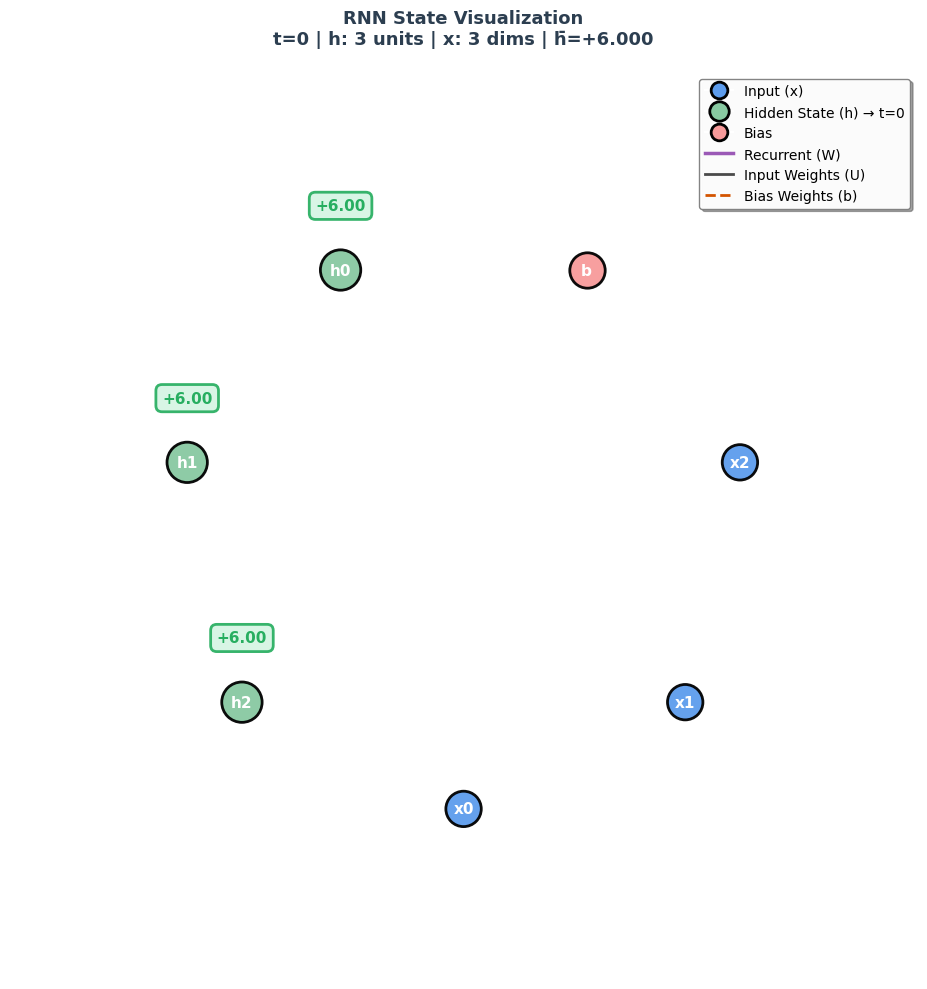

In [193]:
rnn = RecursiveNeuralNetwork(
    inits=[6, 6, 6],
    weights=[[0, 0, 0],
             [0, 0, 0],
             [0, 0, 0]],
    functions=[np.tanh, np.tanh, np.tanh]
)
fig, ax = rnn.visualize(show_weights=True)
plt.show()

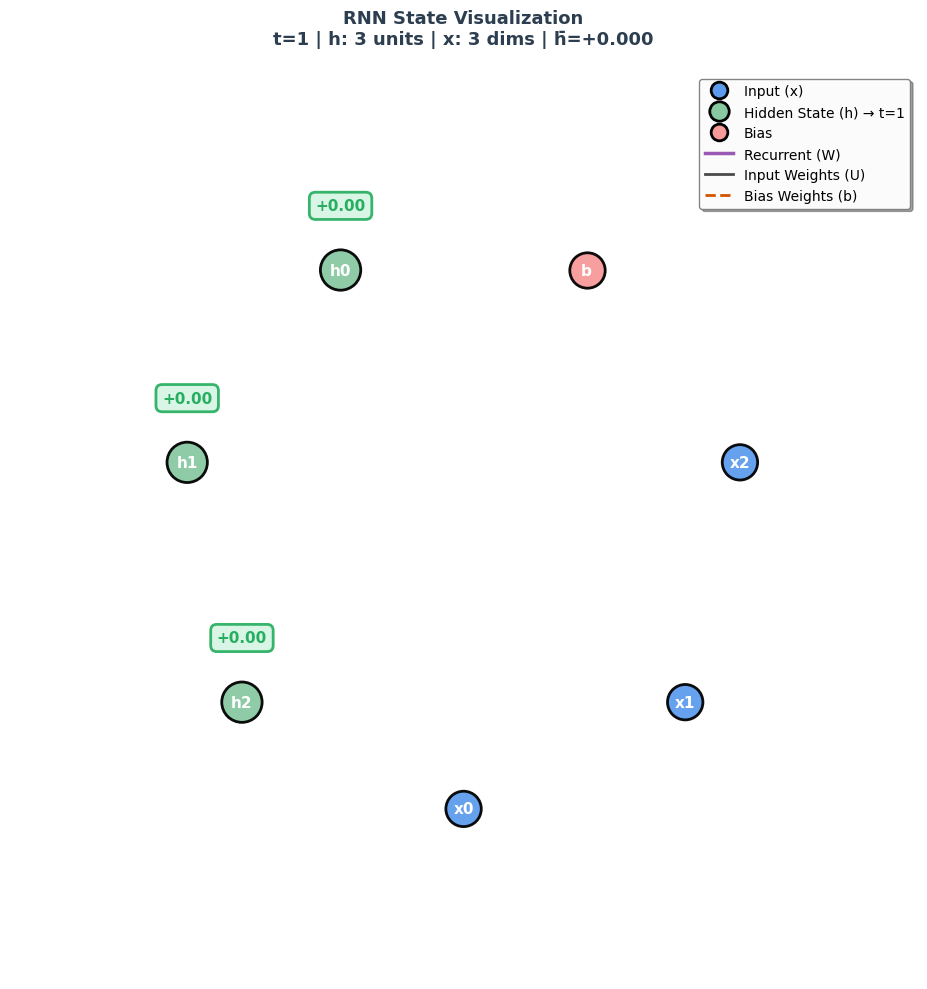

In [194]:
rnn.forward()

fig, ax = rnn.visualize(show_weights=True)
plt.show()

### Second task

In [195]:
rnn = RecursiveNeuralNetwork(
    inits=[0, 0, 0, 1],
    weights=[[0, 1, 0, 0],
             [0, 0, 1, 0],
             [0, 0, 0, 1],
             [1, 0, 0, 0]],
    functions=[lambda x: x, lambda x: x, lambda x: x, lambda x: x]
)

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create animation
fig, ax = plt.subplots(figsize=(10, 10))

def animate(t):
    ax.clear()
    rnn.visualize(ax=ax, show_weights=False, show_values=True, node_size=800, font_size=12)
    rnn.forward()
    ax.set_title(f"Step {t}", fontsize=16)

ani = FuncAnimation(fig, animate, frames=8, interval=400, repeat=True)
plt.close()  # Prevent double display

# Display in notebook
HTML(ani.to_jshtml())

### Third task

In [196]:
# rnn = RecursiveNeuralNetwork(
#     inits=[0, 0, 0, 1],
#     weights=[[0, 10, 0, 0],
#              [0, 0, 10, 0],
#              [0, 0, 0, 10],
#              [10, 0, 0, 0]],
#     functions=[lambda x: x, lambda x: x, lambda x: x, lambda x: x]
# )

rnn = RecursiveNeuralNetwork(
    inits=np.random.randn(3),
    weights=np.random.randn(3, 3),
    functions=[lambda x: x, lambda x: x, lambda x: x]
)


from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create animation
fig, ax = plt.subplots(figsize=(10, 10))

def animate(t):
    ax.clear()
    rnn.forward()
    rnn.visualize(ax=ax, show_weights=False, show_values=True, node_size=800, font_size=12)
    ax.set_title(f"Step {t}", fontsize=16)

ani = FuncAnimation(fig, animate, frames=20, interval=400, repeat=True)
plt.close()  # Prevent double display

# Display in notebook
HTML(ani.to_jshtml())